In [0]:

%%capture
!apt-get install -y -qq software-properties-common python-software-properties module-init-tools
!add-apt-repository -y ppa:fenics-packages/fenics
!apt-get update -qq
!apt install -y --no-install-recommends fenics
!rm -rf *
from dolfin import *

# Exercise 1

## Euler Explicit

In [0]:
n = 20
tMax = 1
Re = Constant(1)
dt = 0.1

u_exact = Expression(('-cos(x[0])*sin(x[1])*sin(2*t)',
                      'sin(x[0])*cos(x[1])*sin(2*t)'), t=0.0, degree=2)

f = Expression((
    '-2 * cos(x[0]) * sin(x[1]) * (cos(2 * t) + sin(2 * t) / Re)',
    '2 * sin(x[0]) * cos(x[1]) * (cos(2 * t) + sin(2 * t) / Re)'
    ), degree=2, t=0.0, Re=Re)

p_exact = Expression('-0.25*(cos(2*x[0])+cos(x[1]))*sin(2*t)*sin(2*t)', t=0.0, degree=2)

mesh = UnitSquareMesh(n, n, 'crossed')
Q = FiniteElement('CG', mesh.ufl_cell(), 1)
V = VectorElement('CG', mesh.ufl_cell(), 2)
X = FunctionSpace(mesh, V*Q)

u, p = TrialFunctions(X)
v, q = TestFunctions(X)

def boundary(x, on_boundary):
  return on_boundary
def origin(x, on_boundary):
  return near(x[0], 0) and near(x[1], 0)

x_ex=Expression(('u[0]', 'u[1]', 'p'), u=u_exact, p=p_exact, degree=2)
x = project(x_ex, X)
u_old, p_old = x.split()

t=0.0
while t<tMax:
  t += dt
  u_exact.t = t
  p_exact.t = t
  f.t = t

  bc =[DirichletBC(X.sub(0), u_exact, boundary),
     DirichletBC(X.sub(1), p_exact, origin, 'pointwise')] 

  a =(dot(u, v)/dt + inner(grad(u), grad(v))/Re - p*div(v) - q*div(u))*dx
  l = (dot(f, v) + dot(u_old, v)/dt - dot(grad(u_old)*u_old, v))*dx
  
  x = Function(X)
  solve(a==l, x, bc)

  uh, ph = x.split()
  u_old = uh

  eH1 = errornorm(u_exact, uh, 'H10')
  eL2 = errornorm(p_exact, ph, 'L2')

  print('time ' + str(t))
  print('eH10  ' + str(eH1))
  print('eL2  ' + str(eL2))
  print()
  print()

time 0.1
eH10  0.0006676566875332003
eL2  0.008394810412694088


time 0.2
eH10  0.001737971467477484
eL2  0.018829690648151348


time 0.30000000000000004
eH10  0.002801733826571586
eL2  0.01780172973189983


time 0.4
eH10  0.00376367834377708
eL2  0.009563958406727656


time 0.5
eH10  0.004577066219062053
eL2  0.022509434850541906


time 0.6
eH10  0.005208080360655098
eL2  0.04957668765989916


time 0.7
eH10  0.005631360498641427
eL2  0.07863163265322326


time 0.7999999999999999
eH10  0.005830073003038462
eL2  0.10441524052265212


time 0.8999999999999999
eH10  0.005796401797355743
eL2  0.12275401529289609


time 0.9999999999999999
eH10  0.005531795339217167
eL2  0.13076454725409306


time 1.0999999999999999
eH10  0.00504686815700318
eL2  0.12722324513588784




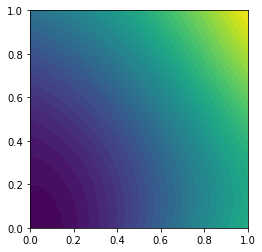

In [0]:
plot(ph)

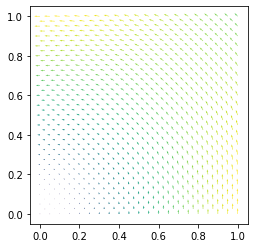

In [0]:
plot(uh)

## Euler Semi-Implicit

In [0]:
n = 20
tMax = 1
Re = Constant(1)
dt = 0.1

u_exact = Expression(('-cos(x[0])*sin(x[1])*sin(2*t)',
                      'sin(x[0])*cos(x[1])*sin(2*t)'), t=0.0, degree=2)

f = Expression((
    '-2 * cos(x[0]) * sin(x[1]) * (cos(2 * t) + sin(2 * t) / Re)',
    '2 * sin(x[0]) * cos(x[1]) * (cos(2 * t) + sin(2 * t) / Re)'
    ), degree=2, t=0.0, Re=Re)

p_exact = Expression('-0.25*(cos(2*x[0])+cos(x[1]))*sin(2*t)*sin(2*t)', t=0.0, degree=2)

mesh = UnitSquareMesh(n, n, 'crossed')
Q = FiniteElement('CG', mesh.ufl_cell(), 1)
V = VectorElement('CG', mesh.ufl_cell(), 2)
X = FunctionSpace(mesh, V*Q)

u, p = TrialFunctions(X)
v, q = TestFunctions(X)

def boundary(x, on_boundary):
  return on_boundary
def origin(x, on_boundary):
  return near(x[0], 0) and near(x[1], 0)

x_ex=Expression(('u[0]', 'u[1]', 'p'), u=u_exact, p=p_exact, degree=2)
x = project(x_ex, X)
u_old, p_old = x.split()

t=0.0
while t<tMax:
  t += dt
  u_exact.t = t
  p_exact.t = t
  f.t = t

  bc =[DirichletBC(X.sub(0), u_exact, boundary),
     DirichletBC(X.sub(1), p_exact, origin, 'pointwise')] 

  a =(dot(u, v)/dt + inner(grad(u), grad(v))/Re - p*div(v) - q*div(u) + dot(grad(u)*u_old, v))*dx
  l = (dot(f, v) + dot(u_old, v)/dt)*dx
  
  x = Function(X)
  solve(a==l, x, bc)

  uh, ph = x.split()
  u_old = uh

  eH1 = errornorm(u_exact, uh, 'H10')
  eL2 = errornorm(p_exact, ph, 'L2')

  print('time ' + str(t))
  print('eH10  ' + str(eH1))
  print('eL2  ' + str(eL2))
  print()
  print()

time 0.1
eH10  0.0006676566875054168
eL2  0.008394810412264284


time 0.2
eH10  0.0017379492520369797
eL2  0.007434823993515234


time 0.30000000000000004
eH10  0.0028015798134611958
eL2  0.005872975147330162


time 0.4
eH10  0.003763285994976386
eL2  0.02398446679749969


time 0.5
eH10  0.004576414921321681
eL2  0.0476492856641644


time 0.6
eH10  0.0052072491714228375
eL2  0.07223433997818833


time 0.7
eH10  0.005630504118097952
eL2  0.09371594332723523


time 0.7999999999999999
eH10  0.005829372710606361
eL2  0.10867313736126626


time 0.8999999999999999
eH10  0.0057960069552412735
eL2  0.114781194849897


time 0.9999999999999999
eH10  0.005531775245546883
eL2  0.11116172337391578


time 1.0999999999999999
eH10  0.005047190783565106
eL2  0.09850443443387807




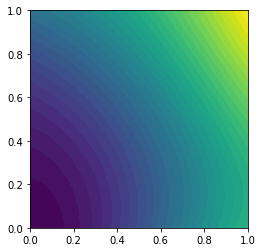

In [0]:
plot(ph)

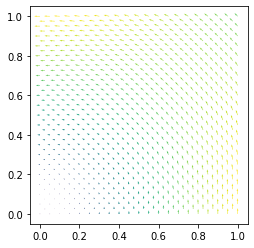

In [0]:
plot(uh)

## Euler Implicit

In [0]:
n = 10
tMax = 1
Re = Constant(1)
dt = 0.1
tol = 1e-8
nMax = 200

u_exact = Expression(('-cos(x[0])*sin(x[1])*sin(2*t)',
                      'sin(x[0])*cos(x[1])*sin(2*t)'), t=0.0, degree=2)

f = Expression((
    '-2 * cos(x[0]) * sin(x[1]) * (cos(2 * t) + sin(2 * t) / Re)',
    '2 * sin(x[0]) * cos(x[1]) * (cos(2 * t) + sin(2 * t) / Re)'
    ), degree=2, t=0.0, Re=Re)

p_exact = Expression('-0.25*(cos(2*x[0])+cos(x[1]))*sin(2*t)*sin(2*t)', t=0.0, degree=2)

mesh = UnitSquareMesh(n, n, 'crossed')
Q = FiniteElement('CG', mesh.ufl_cell(), 1)
V = VectorElement('CG', mesh.ufl_cell(), 2)
X = FunctionSpace(mesh, V*Q)

x_ex=Expression(('u[0]', 'u[1]', 'p'), u=u_exact, p=p_exact, degree=2)
x = project(x_ex, X)
u_old, p_old = x.split()

In [0]:
def solveNewImpl(bc, X, u_old, p_old, tol, nMax, f, Re, dt):
  u, p = TrialFunctions(X)
  v, q = TestFunctions(X)

  uh_old = u_old
  ph_old = p_old

  n = 0
  res = tol+1
  print('Newton Method')
  while res>tol and n<nMax:
    n += 1

    a = (dot(u, v)/dt + inner(grad(u), grad(v))/Re - p*div(v) - q*div(u) + 
         dot(grad(u)*uh_old, v) + dot(grad(uh_old)*u, v))*dx
    l = (dot(f, v) + dot(u_old, v)/dt + dot(grad(uh_old)*uh_old, v))*dx

    x = Function(X)
    solve(a==l, x, bc)

    uh, ph = x.split()

    res = errornorm(uh_old, uh, 'H10')/norm(uh, 'H10') + errornorm(ph_old, ph, 'L2')/norm(ph, 'L2')
    print('It ' + str(n) + ' - residual ' + str(res))
    uh_old, ph_old = uh, ph

  return uh, ph

In [5]:
t=0.0
while t<tMax:
  t += dt
  print('time ' + str(t))
  u_exact.t = t
  p_exact.t = t
  f.t = t
    
  def boundary(x, on_boundary):
    return on_boundary
  def origin(x, on_boundary):
    return near(x[0], 0) and near(x[1], 0)

  bc =[DirichletBC(X.sub(0), u_exact, boundary),
    DirichletBC(X.sub(1), p_exact, origin, 'pointwise')] 

  uh, ph = solveNewImpl(bc, X, u_old, p_old, tol, nMax, f, Re, dt)
  u_old, p_old = uh, ph

  eH1 = errornorm(u_exact, uh, 'H10')
  eL2 = errornorm(p_exact, ph, 'L2')
  print()
  print('Timestep error')
  print('eH10  ' + str(eH1))
  print('eL2  ' + str(eL2))
  print()
  print()
  print()

time 0.1
Newton Method
It 1 - residual 1.999999999999992
It 2 - residual 1.0603533476139193
It 3 - residual 2.1887712902752168e-11

Timestep error
eH10  0.000671610460645253
eL2  0.0049994064225369885



time 0.2
Newton Method
It 1 - residual 1.2613561118740886
It 2 - residual 0.26547896918109953
It 3 - residual 7.2438798322190455e-12

Timestep error
eH10  0.0017438508175792473
eL2  0.01724260724744116



time 0.30000000000000004
Newton Method
It 1 - residual 0.8566247842554243
It 2 - residual 0.10809618016277206
It 3 - residual 5.6694539141922525e-12

Timestep error
eH10  0.002809373699970565
eL2  0.03574597192802114



time 0.4
Newton Method
It 1 - residual 0.6061488556750699
It 2 - residual 0.05117033984130556
It 3 - residual 3.519147241435073e-12

Timestep error
eH10  0.0037728002282369656
eL2  0.05789884884705934



time 0.5
Newton Method
It 1 - residual 0.42756736966172415
It 2 - residual 0.024632893935616018
It 3 - residual 2.6633203794299987e-12

Timestep error
eH10  0.00458738

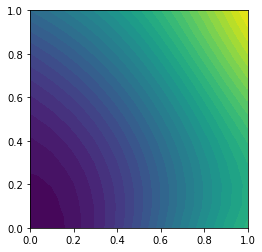

In [6]:
plot(ph)

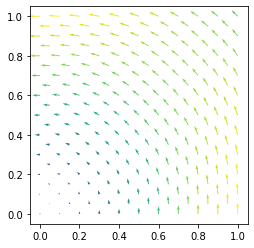

In [0]:
plot(uh)

# Exercise 2

## Without Stabilization

In [0]:
u_top = Constant((1, 0))
u_other = Constant((0, 0))

f = Constant((0, 0))
n=40
tMax = 10
Re = Constant(10000)
dt = 0.1

mesh = UnitSquareMesh(n, n, 'crossed')

# Space Definition
V = VectorElement('CG', mesh.ufl_cell(), 2)
Q = FiniteElement('CG', mesh.ufl_cell(), 1)

X = FunctionSpace(mesh, V*Q)

In [0]:
# Boundary
def top(x, on_boundary):
  return near(x[1], 1)
def other(x, on_boundary):
  return on_boundary and not near(x[1], 1)
def origin(x, on_boundary):
  return near(x[0], 0) and near(x[1], 0)

bc1 = DirichletBC(X.sub(0), u_top, top)
bc2 = DirichletBC(X.sub(0), u_other, other)
bc3 = DirichletBC(X.sub(1), Constant(0), origin, 'pointwise')
bcs=[bc1, bc2, bc3]

In [0]:
u, p = TrialFunctions(X)
v, q = TestFunctions(X)

a = (inner(grad(u), grad(v))/Re - p*div(v) - q*div(u))*dx
l = dot(f, v)*dx

x = Function(X)
solve(a==l, x, bcs)
u, p = x.split()
ufile = File('velocity.pvd')
pfile = File('pressure.pvd')
t=0
ufile << (u, t)
pfile << (p, t)

while t<tMax:
  t += dt

  u_old, p_old = u, p

  u, p = TrialFunctions(X)
  v, q = TestFunctions(X)

  a = (dot(u, v)/dt + inner(grad(u), grad(v))/Re + dot(grad(u)*u_old, v) - p*div(v) - q*div(u))*dx
  l = (dot(f, v) + dot(u_old, v)/dt)*dx
  
  x = Function(X)
  solve(a==l, x, bcs)
  u, p = x.split()
  ufile << (u, t)
  pfile << (p, t)

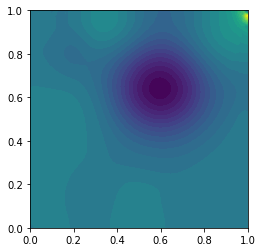

In [0]:
plot(p)

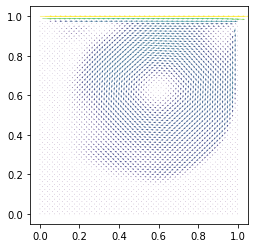

In [0]:
plot(u)

## With Stabilization

In [0]:
u_top = Constant((1, 0))
u_other = Constant((0, 0))
f = Constant((0, 0))
n=20
tMax = 1
Re = Constant(10000)
dt = 0.1

mesh = UnitSquareMesh(n, n, 'crossed')

# Space Definition
V = VectorElement('CG', mesh.ufl_cell(), 2)
Q = FiniteElement('CG', mesh.ufl_cell(), 1)

X = FunctionSpace(mesh, V*Q)

# Boundary
def top(x, on_boundary):
  return near(x[1], 1)
def other(x, on_boundary):
  return on_boundary and not near(x[1], 1)
def origin(x, on_boundary):
  return near(x[0], 0) and near(x[1], 0)

bc1 = DirichletBC(X.sub(0), u_top, top)
bc2 = DirichletBC(X.sub(0), u_other, other)
bc3 = DirichletBC(X.sub(1), Constant(0), origin, 'pointwise')
bcs=[bc1, bc2, bc3]

u, p = TrialFunctions(X)
v, q = TestFunctions(X)

a = (inner(grad(u), grad(v))/Re - p*div(v) - q*div(u))*dx
l = dot(f, v)*dx

x = Function(X)
solve(a==l, x, bcs)
u, p = x.split()
ufile = File('velocity.pvd')
pfile = File('pressure.pvd')
ufile << (u, t)
pfile << (p, t)

t=0
while t<tMax:
  t += dt

  u_old, p_old = u, p

  u, p = TrialFunctions(X)
  v, q = TestFunctions(X)

  # pay attention to the sign of the last term here! In the case of stabilized FEM 
  # we have to put a plus sign in orther to match with the skew-symmetry requirement
  # of the SUPG formulation of the stabilization term... otherwise we should modify 
  # the signs in the stabilization terms
  a = (dot(u, v)/dt + inner(grad(u), grad(v))/Re + dot(grad(u)*u_old, v) - p*div(v) + q*div(u))*dx
  l = (dot(f, v) + dot(u_old, v)/dt)*dx

  h=CellDiameter(mesh)
  unorm=sqrt(dot(u_old, u_old))
  Pe = unorm*h*Re/2
  eps = conditional(Pe>1, 1, Pe)
  tau = h*eps/(2*unorm)

  A = lambda u, p: u / Constant(dt) + (grad(u) * u_old) - div(grad(u)) / Re + grad(p)
  A_SS = lambda u, p: (grad(u) * u_old) + grad(p) + 0.5 * div(u_old) * u
  a += tau * (dot(A(u, p), A_SS(v, q)) + div(u) * div(v)) * dx
  l += tau * (dot(u_old / Constant(dt) + f, A_SS(v, q))) * dx

  x = Function(X)
  solve(a==l, x, [bc1, bc2, bc3])
  u, p = x.split()
  ufile << (u, t)
  pfile << (p, t)

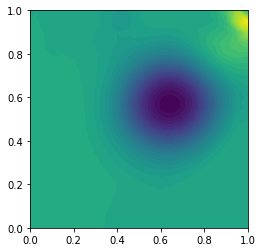

In [0]:
plot(p)

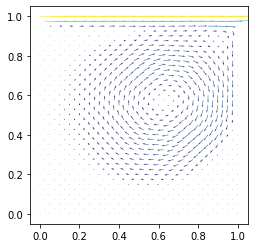

In [0]:
plot(u)